# Final Proyect: Sports Analytics using Deep Learning Models

**Universidad de Monterrey**  
**Curso:** Inteligencia Artificial II  
**Estudiantes:**

María Elisa Olivares Quiroga #611066  
Sergio Alejandro Zamora Dávila #616148  
**Profesor:** Dr. Andrés Hernández Gutiérrez  
**Fecha:** 21 de Mayo, 2026

El proyecto que hemos realizado es una solución a un problema de detección de objetos aplicado al análisis deportivo, utilizamos técnicas aprendidas en el curso de Inteligencia Artificial II como deep learning y visión computacional. Implementamos un modelo basado en YOLO para detectar jugadores y al balón en un video aéreo de un partido de fútbol. Además de detectar a los jugadores y al balón el resultado también muestra distintas métricas que tienen que ver con la posición del balón y de los jugadores.

#### Configuración Inicial

Para poder comenzar con el proyecto, configuramos e instalamos las herramientas necesarias para el pipeline. Como nuestro proyecto utiliza transfer learning con YOLOv11, primero instalamos la librería Ultralytics, que proporciona el modelo y sus herramientas.

Luego importamos las librerías necesarias para procesar imágenes, manejar archivos, entrenar al modelo y realizar operaciones matemáticas. Utilizamos OpenCV, NumPy, PyTorch y YOLO de Ultralytics. Finalmente, montamos Google Drive en Google Colab para acceder fácilmente a las carpetas del proyecto y trabajar de forma colaborativa entre los integrantes del equipo.

In [ ]:
!pip install ultralytics -q

import cv2
import os
import shutil
import random
import glob
import torch
import numpy as np
import yaml
import matplotlib.pyplot as plt
import os
from ultralytics import YOLO
from google.colab import drive
from IPython.display import Image

drive.mount('/content/drive')

Mounted at /content/drive


#### Definición de rutas

Utilizamos diferentes carpetas en Google Drive para organizar los archivos del proyecto. Separamos imágenes preprocesadas, etiquetas, datasets, resultados de entrenamiento y videos de salida. Google Drive nos ayudó con un fácil acceso desde Google Colab y fue fácil hacer un trabajo colaborativo más organizado entre nosotros.

In [ ]:
base_dir = "/content/drive/MyDrive/FinalProject_SportsAnalytics"

images_dir = os.path.join(base_dir, "Pre-processed_images")
labels_dir = os.path.join(base_dir, "labels_yolo")
dataset_dir = os.path.join(base_dir, "dataset_yolo")
runs_dir = os.path.join(base_dir, "runs")

video_path = os.path.join(base_dir, "dataset_proyectofinal.mp4")
output_video_path = os.path.join(base_dir, "output_detections.mp4")

#### Dataset de entrenamiento

Para realizar el proyecto, se nos proporcionó un video aéreo de 12 jugadores jugando fútbol dentro de una cancha de la UDEM. Debido a esto, para poder entrenar el modelo de deep learning tuvimos que construir un dataset de entrenamiento a partir del video proporcionado. Siguiendo las recomendaciones del proyecto, trabajamos con 600 imágenes.

Para crear el dataset, primero extrajimos frames del video original. El objetivo fue obtener imágenes representativas de diferentes momentos del partido para capturar distintas posiciones de jugadores y balón. A continuación mostramos el código que usamos para extraer los frames. Sin embargo, las imágenes resultantes ya están almacenadas en images_dir.


```
video_path = os.path.join(base_dir, "dataset_proyectofinal.mp4")
num_frames = 600

os.makedirs(images_dir, exist_ok=True)

video_capture = cv2.VideoCapture(video_path)
total_frames  = int(video_capture.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"Frames totales en video: {total_frames}")

frame_step = total_frames // num_frames
count = 0
frame_index = 0

while count < num_frames and video_capture.isOpened():
    success, frame = video_capture.read()
    if not success:
        break
    if frame_index % frame_step == random.randint(0, frame_step - 1):
        file_name = os.path.join(images_dir, f"frame_{count}.jpg")
        cv2.imwrite(file_name, frame)
        count += 1
    frame_index += 1

video_capture.release()
print(f"Frames guardados: {count}")
```

El código comienza definiendo la ruta del video original y la cantidad de frames que deseamos extraer. Luego creamos la carpeta donde almacenaremos las imágenes si no existe. Con OpenCV, cargamos el video y obtuvimos el número total de frames disponibles.

Después calculamos un intervalo entre frames (frame_step) para distribuir las imágenes seleccionadas a lo largo de todo el video. Durante el recorrido seleccionamos frames de manera semialeatoria dentro de cada intervalo y los guardamos como imágenes en formato .jpg.

Finalmente, liberamos el video cargado y mostramos la cantidad total de frames guardados correctamente para el dataset de entrenamiento.

Una vez seleccionadas las imágenes preprocesadas, las subimos a CVAT (Computer Vision Annotation Tool), una plataforma para anotar imágenes y videos con el objetivo de entrenar modelos de visión computacional. Después de cargar las imágenes, definimos las dos etiquetas necesarias: player y ball. Realizamos la anotación manual trazando los bounding boxes para cada jugador y balón en los 600 frames. Una vez terminada la anotación, descargamos las etiquetas en formato YOLO para usarlas en entrenamiento y validación. Guardamos estas etiquetas en formato .txt en labels_yolo.

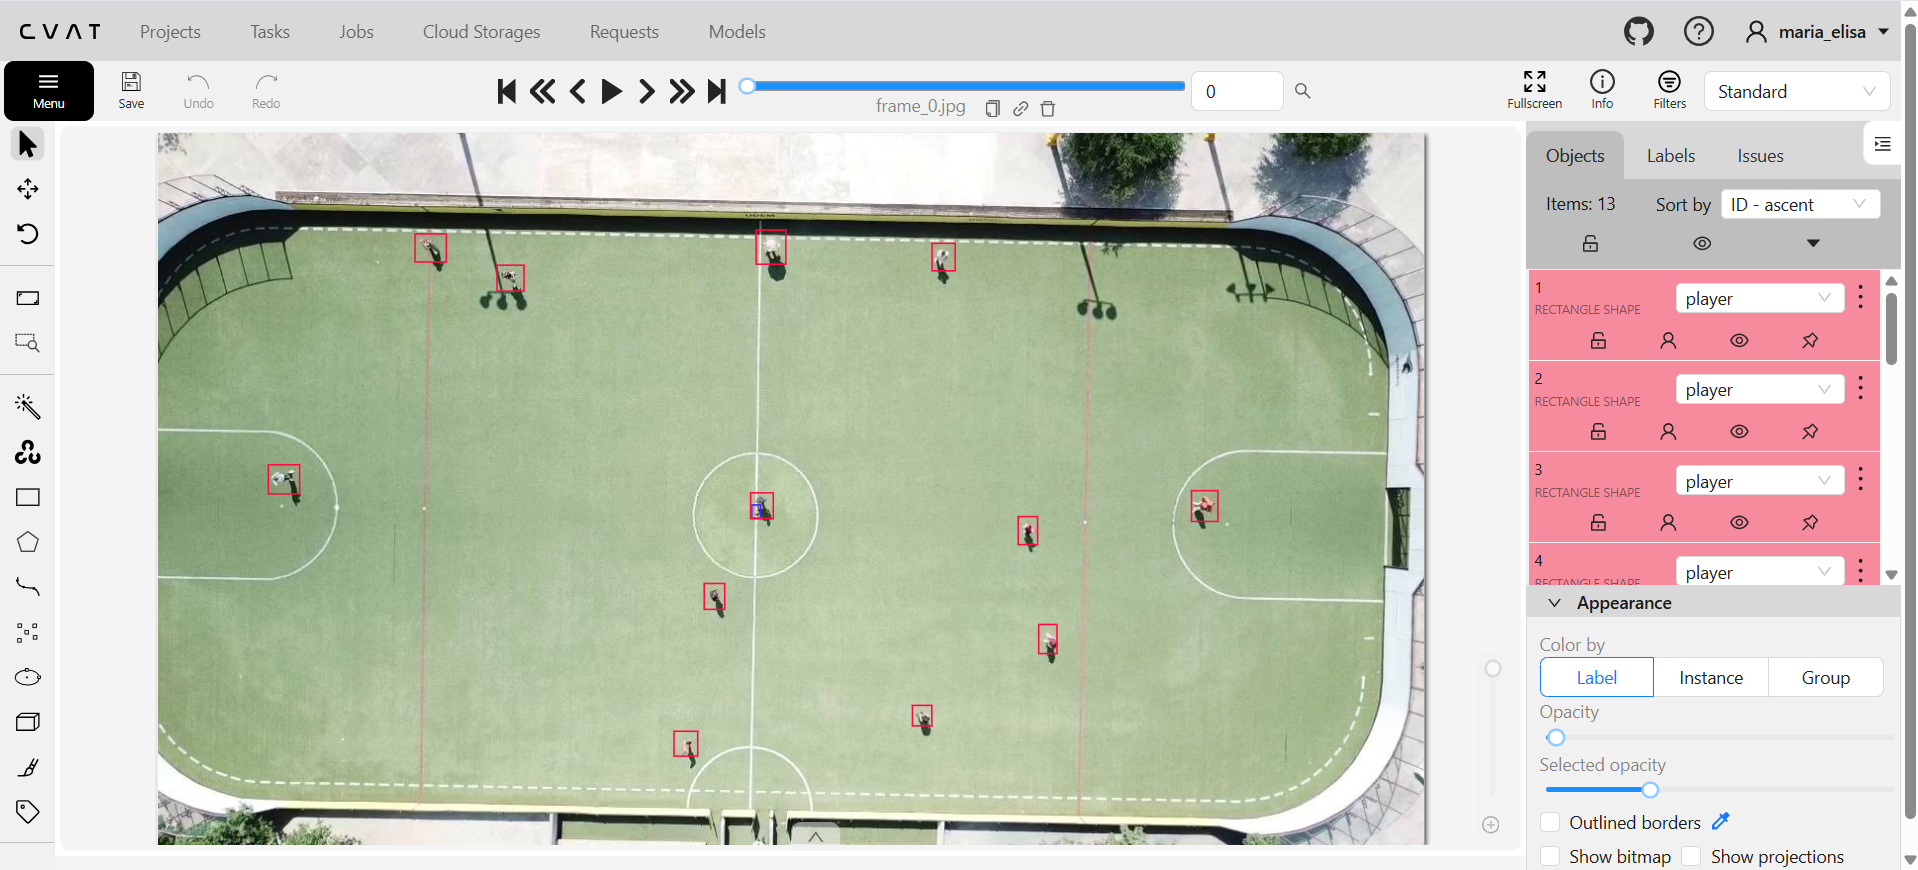

In [ ]:
display(Image(filename=os.path.join(base_dir, 'cvat_example.png')))

#### División de dataset

Con las anotaciones y frames listos, organizamos las imágenes y etiquetas en la estructura necesaria para entrenar el modelo YOLO. Dividimos el dataset en tres subconjuntos: entrenamiento (train), validación (validation) y prueba (test).

El código crea automáticamente la estructura de carpetas para cada subconjunto, con directorios independientes para imágenes y etiquetas. Luego obtuvimos todas las imágenes y las mezclamos aleatoriamente usando una semilla fija (seed = 42). Esto nos permitió mantener reproducibilidad en la división, asegurando que la distribución fuera siempre igual.

Después calculamos los porcentajes para cada subconjunto. Utilizamos una división de 70% para entrenamiento, 15% para validación y 15% para pruebas. El conjunto de entrenamiento permitió que el modelo aprendiera patrones visuales, mientras que validación y prueba nos permitieron evaluar el desempeño con imágenes nuevas.

Finalmente, el código copió automáticamente las imágenes y sus etiquetas en formato YOLO hacia las carpetas correspondientes. Al finalizar, mostramos la cantidad total de imágenes y cuántas pertenecían a cada división.

In [ ]:
# Obtener imágenes y hacer split
all_images = sorted(glob.glob(os.path.join(images_dir, "*.jpg")))
random.seed(42)
random.shuffle(all_images)

n = len(all_images)
n_train = int(n * 0.70)
n_val = int(n * 0.15)

splits = {
    "train": all_images[:n_train],
    "val": all_images[n_train:n_train+n_val],
    "test": all_images[n_train+n_val:]
}

# Crear estructura y copiar archivos
for split in ["train", "val", "test"]:
    for img_path in splits[split]:
        name = os.path.basename(img_path)
        base_name = os.path.splitext(name)[0]
        label_path = os.path.join(labels_dir, base_name + ".txt")

        shutil.copy(img_path, os.path.join(dataset_dir, split, "images", name))
        if os.path.exists(label_path):
            shutil.copy(label_path, os.path.join(dataset_dir, split, "labels", base_name + ".txt"))

print(f"Dataset: {n} imágenes | Train: {len(splits['train'])} | Val: {len(splits['val'])} | Test: {len(splits['test'])}")

Dataset: 600 imágenes | Train: 420 | Val: 90 | Test: 90


#### Configuración del Archivo YAML para YOLO

Una vez organizada la estructura del dataset, creamos un archivo en formato YAML que YOLO utiliza para identificar la ubicación de las imágenes y las clases detectadas durante el entrenamiento.

En este archivo definimos la ruta principal del dataset y las carpetas de entrenamiento, validación y prueba. También especificamos el número total de clases (nc = 2) y sus nombres: player y ball.

Guardamos el archivo YAML automáticamente. Este archivo funciona como referencia para el modelo durante el entrenamiento, permitiendo que YOLO cargue correctamente las imágenes, etiquetas y clases del proyecto.

In [ ]:
yaml_path = os.path.join(dataset_dir, "data.yaml")
with open(yaml_path, 'w') as f:
    yaml.dump({
        "path": dataset_dir,
        "train": "train/images",
        "val": "val/images",
        "test": "test/images",
        "nc": 2,
        "names": {0: "player", 1: "ball"}
    }, f)

print(f"Archivo YAML creado: {yaml_path}")

Archivo YAML creado: /content/drive/MyDrive/FinalProject_SportsAnalytics/dataset_yolo/data.yaml


#### Entrenamiento con Transfer Learning

Una vez preparado el dataset y configurado el archivo YAML, iniciamos el entrenamiento del modelo usando transfer learning con YOLO11n. Para mejorar la estabilidad y aprovechar las características aprendidas previamente, implementamos un entrenamiento dividido en tres fases.

*Fase 1: Entrenamiento de la cabeza del detector*

Durante la primera fase, congelamos el backbone de la red neuronal y entrenamos solo la cabeza del detector (head). El backbone extrae características generales de la imagen, mientras que la cabeza realiza la detección y clasificación de objetos. Esta estrategia nos permitió adaptar el detector a las nuevas clases (player y ball) sin modificar las características aprendidas previamente.

Para esta etapa usamos resolución de entrada de 640x640 píxeles, batch size de 16 imágenes y un learning rate bajo para evitar cambios bruscos. Además implementamos early stopping con el parámetro patience para evitar sobreentrenamiento si el desempeño dejaba de mejorar.

In [ ]:
model = YOLO("yolo11n.pt")

print("FASE 1: Fine-tuning de la Cabeza (Épocas 1-30)")
print("Backbone CONGELADO | Head ACTIVO\n")

for name, param in model.named_parameters():
    if "head" not in name:
        param.requires_grad = False

model.train(
    data=yaml_path,
    epochs=30,
    imgsz=640,
    batch=16,
    patience=5,
    name="yolo11n_soccer_phase1",
    project=runs_dir,
    device=0,
    lr0=0.0001,
    lrf=0.001,
    warmup_epochs=3,
    weight_decay=0.0005,
    verbose=True
)

print("Fase 1 completada")

FASE 1: Fine-tuning de la Cabeza (Épocas 1-30)
Backbone CONGELADO | Head ACTIVO

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/FinalProject_SportsAnalytics/dataset_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.001, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0

*Fase 2: Descongelamiento parcial del backbone*

Después de completar la primera fase, procedimos con una segunda fase donde descongelamos parcialmente algunas capas del backbone y mantuvimos activa la cabeza del detector. El objetivo fue permitir que el modelo ajustara características más específicas, como la apariencia de jugadores desde perspectiva aérea y el tamaño del balón.

Para esta fase, primero cargamos automáticamente el mejor modelo de la fase anterior. Luego habilitamos el entrenamiento de las últimas capas del backbone junto con la cabeza, mientras que el resto permanecieron congeladas. Esta estrategia nos permitió ajustar de mejor forma sin perder el conocimiento previo.

Además reducimos más el learning rate para poder hacer modificaciones controladas en los parámetros. Mantuvimos resolución y batch size similares para conservar estabilidad.

In [ ]:
print("FASE 2: Descongelamiento de Capas (Épocas 31-70)")
print("Últimas capas + Head ACTIVOS\n")

best_phase1 = os.path.join(runs_dir, "yolo11n_soccer_phase1", "weights", "best.pt")
model = YOLO(best_phase1)

for name, param in model.named_parameters():
    if "head" not in name and "C3k2" not in name:
        param.requires_grad = False

model.train(
    data=yaml_path,
    epochs=70,
    imgsz=640,
    batch=16,
    patience=8,
    name="yolo11n_soccer_phase2",
    project=runs_dir,
    device=0,
    lr0=0.00005,
    lrf=0.0001,
    warmup_epochs=2,
    weight_decay=0.0005,
    verbose=True
)

print("Fase 2 completada")

FASE 2: Descongelamiento de Capas (Épocas 31-70)
Últimas capas + Head ACTIVOS

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/FinalProject_SportsAnalytics/dataset_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=70, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=5e-05, lrf=0.0001, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/FinalProject_Spor

*Fase 3: Fine-tuning completo del modelo*

Finalmente, en la tercera fase realizamos un fine-tuning completo donde descongelamos todos los parámetros de la red. El objetivo fue refinar completamente el desempeño del modelo y optimizar la detección de jugadores y balón.

Como en la fase anterior, primero cargamos el mejor modelo de la Fase 2 y continuamos con un learning rate extremadamente bajo. Esto nos permitió hacer ajustes pequeños y precisos en todos los pesos sin perder el conocimiento aprendido.

In [ ]:
print("FASE 3: Fine-tuning Completo (Épocas 71-100)")
print("Todos los parámetros ACTIVOS\n")

best_phase2 = os.path.join(runs_dir, "yolo11n_soccer_phase2", "weights", "best.pt")
model = YOLO(best_phase2)

model.train(
    data=yaml_path,
    epochs=100,
    imgsz=640,
    batch=16,
    patience=10,
    name="yolo11n_soccer_final",
    project=runs_dir,
    device=0,
    lr0=0.00001,
    lrf=0.00001,
    warmup_epochs=0,
    weight_decay=0.0005,
    verbose=True
)

print("Fase 3 completada")

FASE 3: Fine-tuning Completo (Épocas 71-100)
Todos los parámetros ACTIVOS

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/FinalProject_SportsAnalytics/dataset_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=1e-05, lrf=1e-05, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/FinalProject_SportsAn

Esta estrategia de tres fases nos ayudó a mantener un entrenamiento más estable. Además de que la encontramos especialmente útil para mejorar la detección del balón, ya que fue la clase más difícil por su tamaño reducido y movimiento constante.

#### Guardar modelo

Una vez finalizado el entrenamiento completo, guardamos el mejor modelo obtenido. YOLO genwea el archivo best.pt, que contiene los pesos con el mejor desempeño.

Después copiamos este archivo y lo almacenamos en la carpeta principal con un nombre más identificable (yolo11n_soccer_best.pt). Esto facilitó el acceso al modelo para etapas futuras.

Finalmente, mostramos la ubicación donde guardamos el modelo final, confirmando que el proceso si funcionó.

In [ ]:
best_weights = os.path.join(runs_dir, "yolo11n_soccer_final", "weights", "best.pt")
final_model = os.path.join(base_dir, "yolo11n_soccer_best.pt")
shutil.copy(best_weights, final_model)

print("Modelo final guardado en:", final_model)

Modelo final guardado en: /content/drive/MyDrive/FinalProject_SportsAnalytics/yolo11n_soccer_best.pt


#### Validación del modelo

Una vez entrenado y guardado el modelo, realizamos la validación con el conjunto de prueba. Primero generamos un nuevo archivo YAML con las rutas de entrenamiento, validación y prueba, además de las clases del modelo.

Después cargamos el modelo entrenado y ejecutamos la validación en el conjunto de prueba usando imágenes de 640x640 píxeles.

Obtuvimos métricas como mAP@50 y mAP@50-95, que miden la precisión considerando la superposición entre bounding boxes predichos y reales. También calculamos Precision y Recall. Precision indica qué porcentaje de detecciones fueron correctas, mientras que Recall mide cuántos objetos reales fueron detectados correctamente.

Estas métricas nos permitieron evaluar el desempeño del modelo y analizar las dificultades del problema.

In [ ]:
yaml_plain_path = os.path.join(dataset_dir, "data.yaml")
with open(yaml_plain_path, "w") as f:
    yaml.dump({
        "train": os.path.join(dataset_dir, "train", "images"),
        "val": os.path.join(dataset_dir, "val", "images"),
        "test": os.path.join(dataset_dir, "test", "images"),
        "nc": 2,
        "names": ["player", "ball"]
    }, f, default_flow_style=False)

trained_model = YOLO(os.path.join(base_dir, "yolo11n_soccer_best.pt"))
metrics = trained_model.val(data=yaml_plain_path, split="test", imgsz=640, device=0)

print("\nResultados del modelo")
print(f"mAP@50:    {metrics.box.map50:.4f}")
print(f"mAP@50-95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall:    {metrics.box.mr:.4f}")

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 1.0±0.5 ms, read: 0.4±0.3 MB/s, size: 309.4 KB)
val: Scanning /content/drive/.shortcut-targets-by-id/1f_uKaMshEosnaeWhmi-pgc5Zv6M6m8BT/FinalProject_SportsAnalytics/dataset_yolo/test/labels.cache... 258 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 258/258 40.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 17/17 1.1it/s 16.1s
                   all        258       3354      0.922      0.781      0.795       0.44
                player        258       3096      0.994      0.996      0.994       0.64
                  ball        258        258      0.849      0.566      0.596       0.24
Speed: 1.4ms preprocess, 3.5ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/detect/val

Resul

## Resultados del modelo
Los resultados muestran que nuestro modelo logró un desempeño satisfactorio en la detección de jugadores y balón. La precision fue cercana a 0.92, indicando que la mayoría de detecciones fueron correctas con pocos falsos positivos. Esto se observó principalmente en jugadores, donde el modelo identificó correctamente a la mayoría de participantes.

El recall fue aproximadamente 0.78, indicando que aunque detectamos correctamente gran parte de los objetos, existieron casos donde algunos no fueron detectados. Este problema pasa más que nada con el balón, debido a su tamaño reducido, movimiento rápido y que muchas veces este terminaba bloqueado por algún jugador.

El mAP@50 = 0.7950 indica una buena capacidad de localización y clasificación. Sin embargo, mAP@50-95 = 0.4400, este valor disminuye considerablemente con criterios más estrictos. Lo que estos valores significan es que aunque detectamos correctamente, la precisión exacta de los bounding boxes puede mejorar.



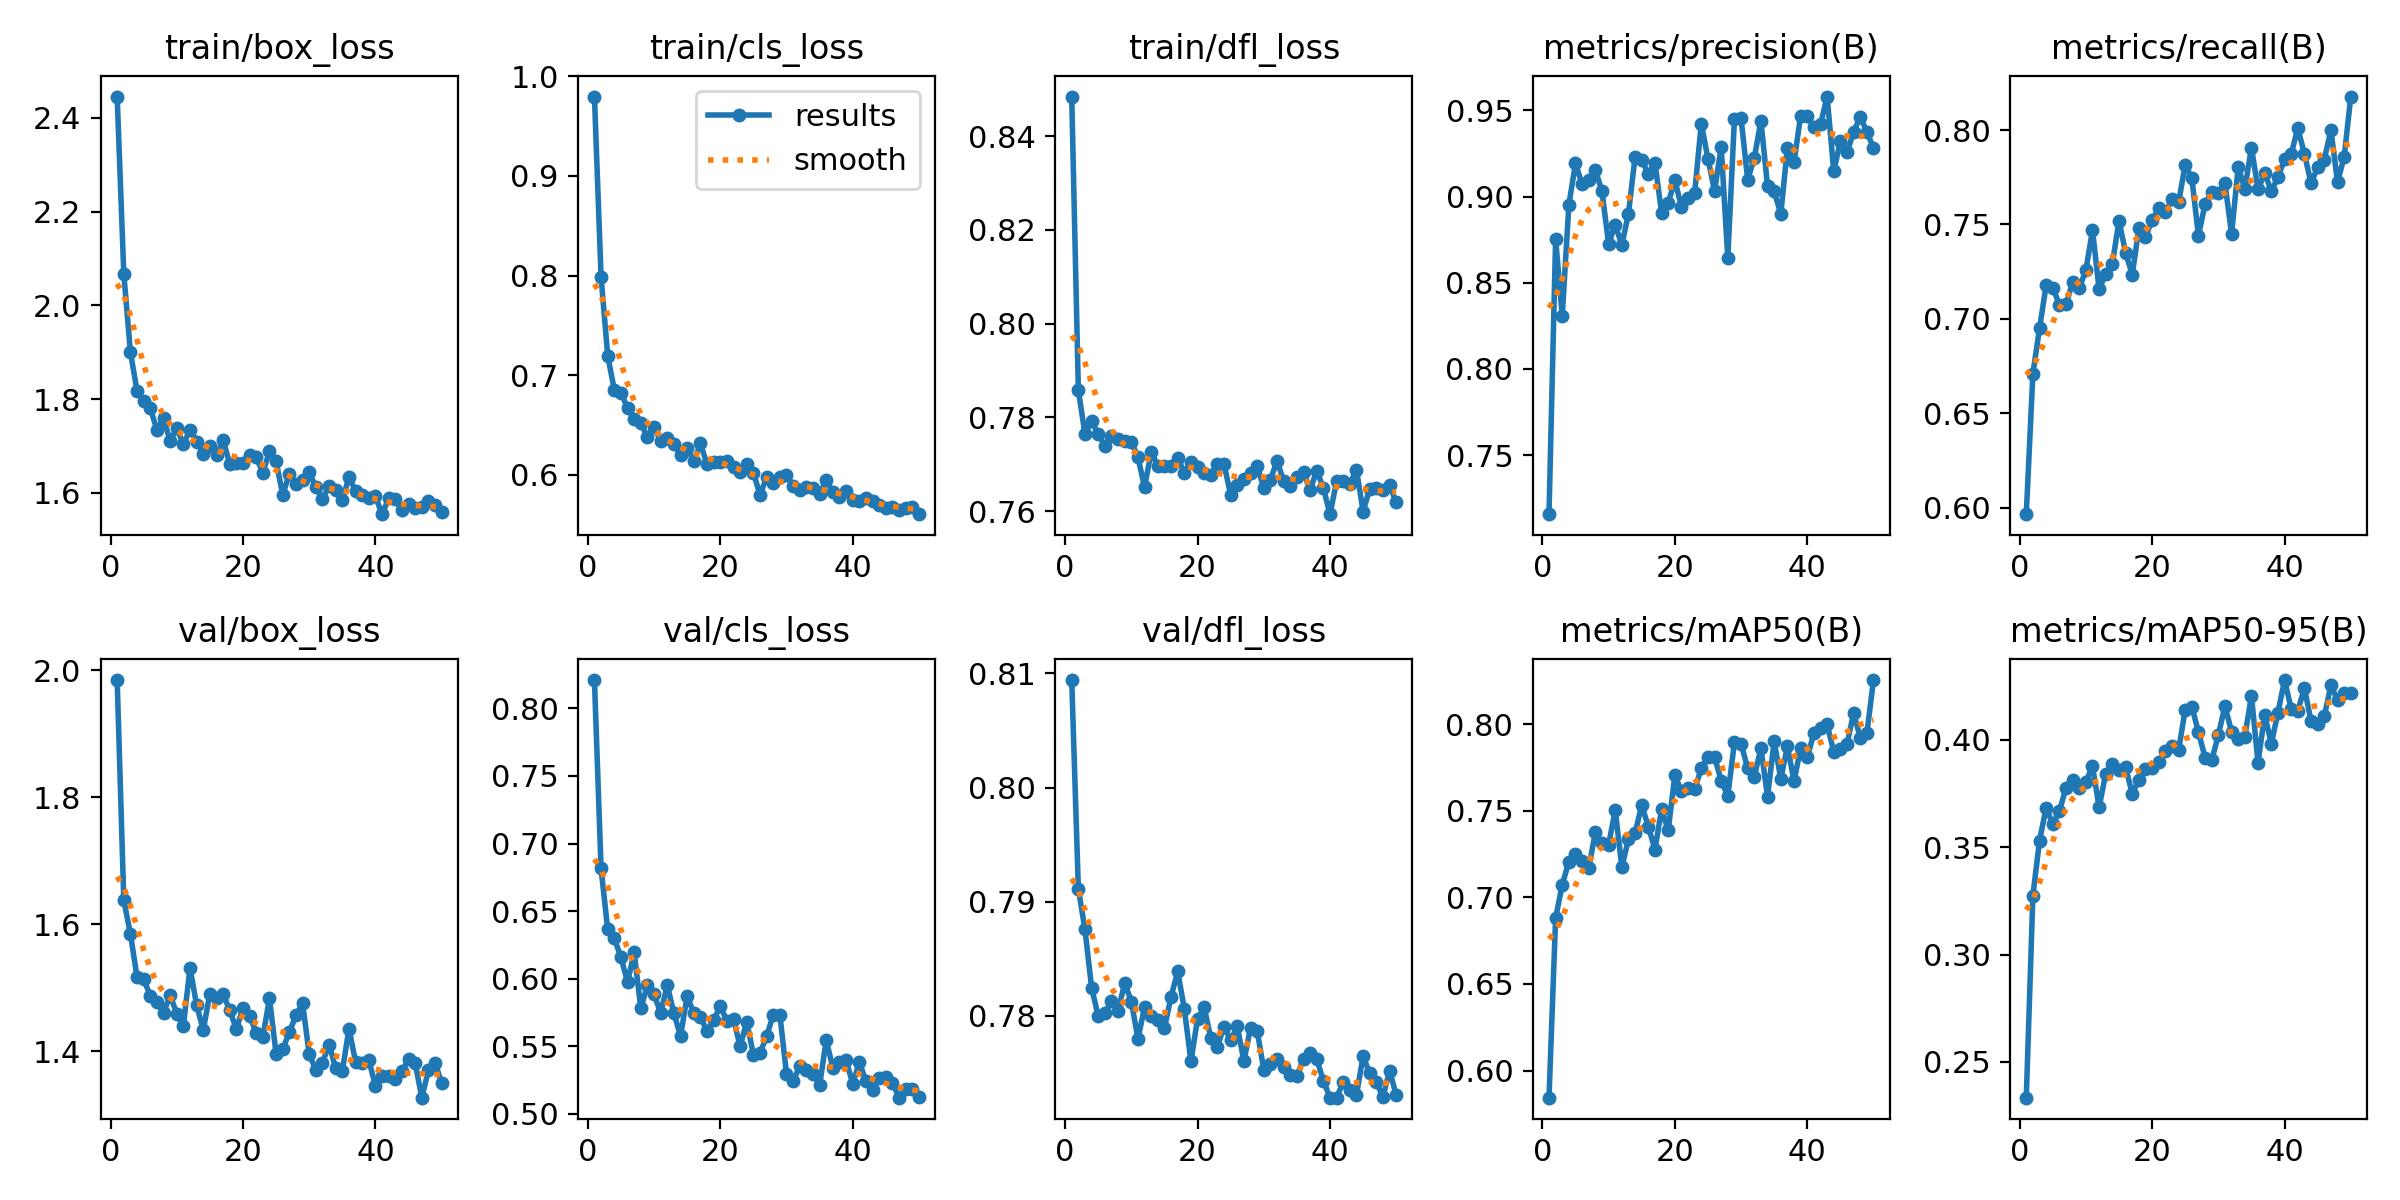

In [ ]:
display(Image(filename=os.path.join(runs_dir, 'yolo11n_soccer_final-3', 'results.png')))

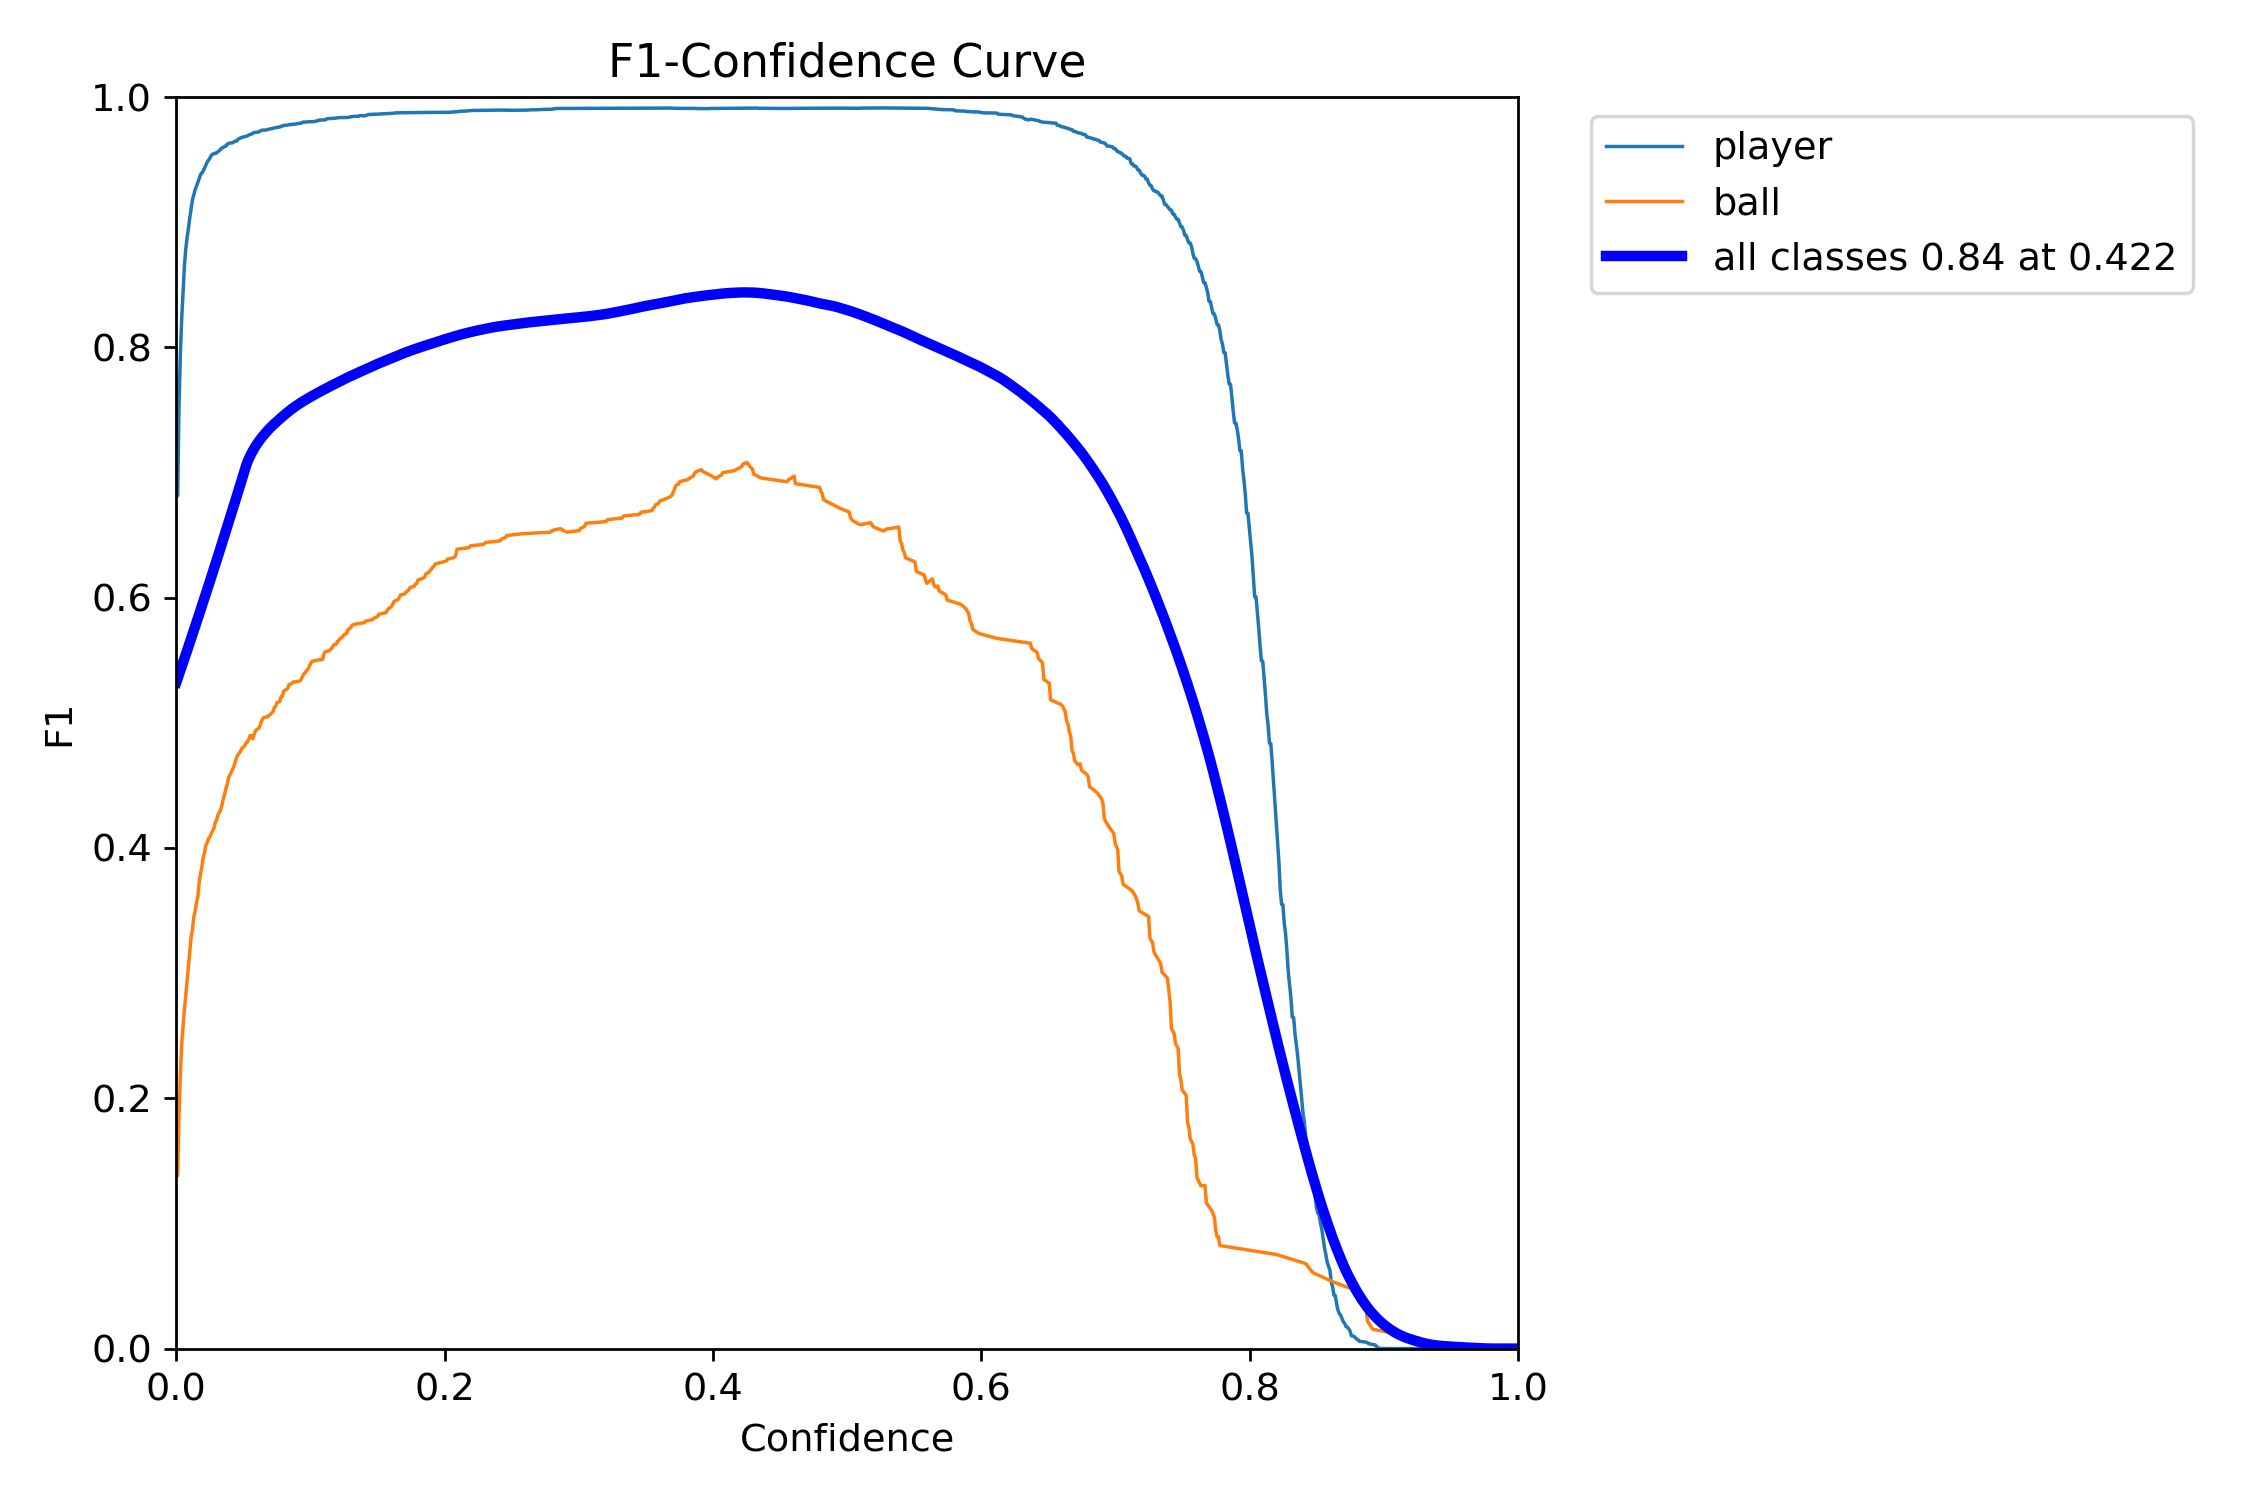

In [ ]:
display(Image(filename=os.path.join(runs_dir, 'yolo11n_soccer_final-3', 'BoxF1_curve.png')))

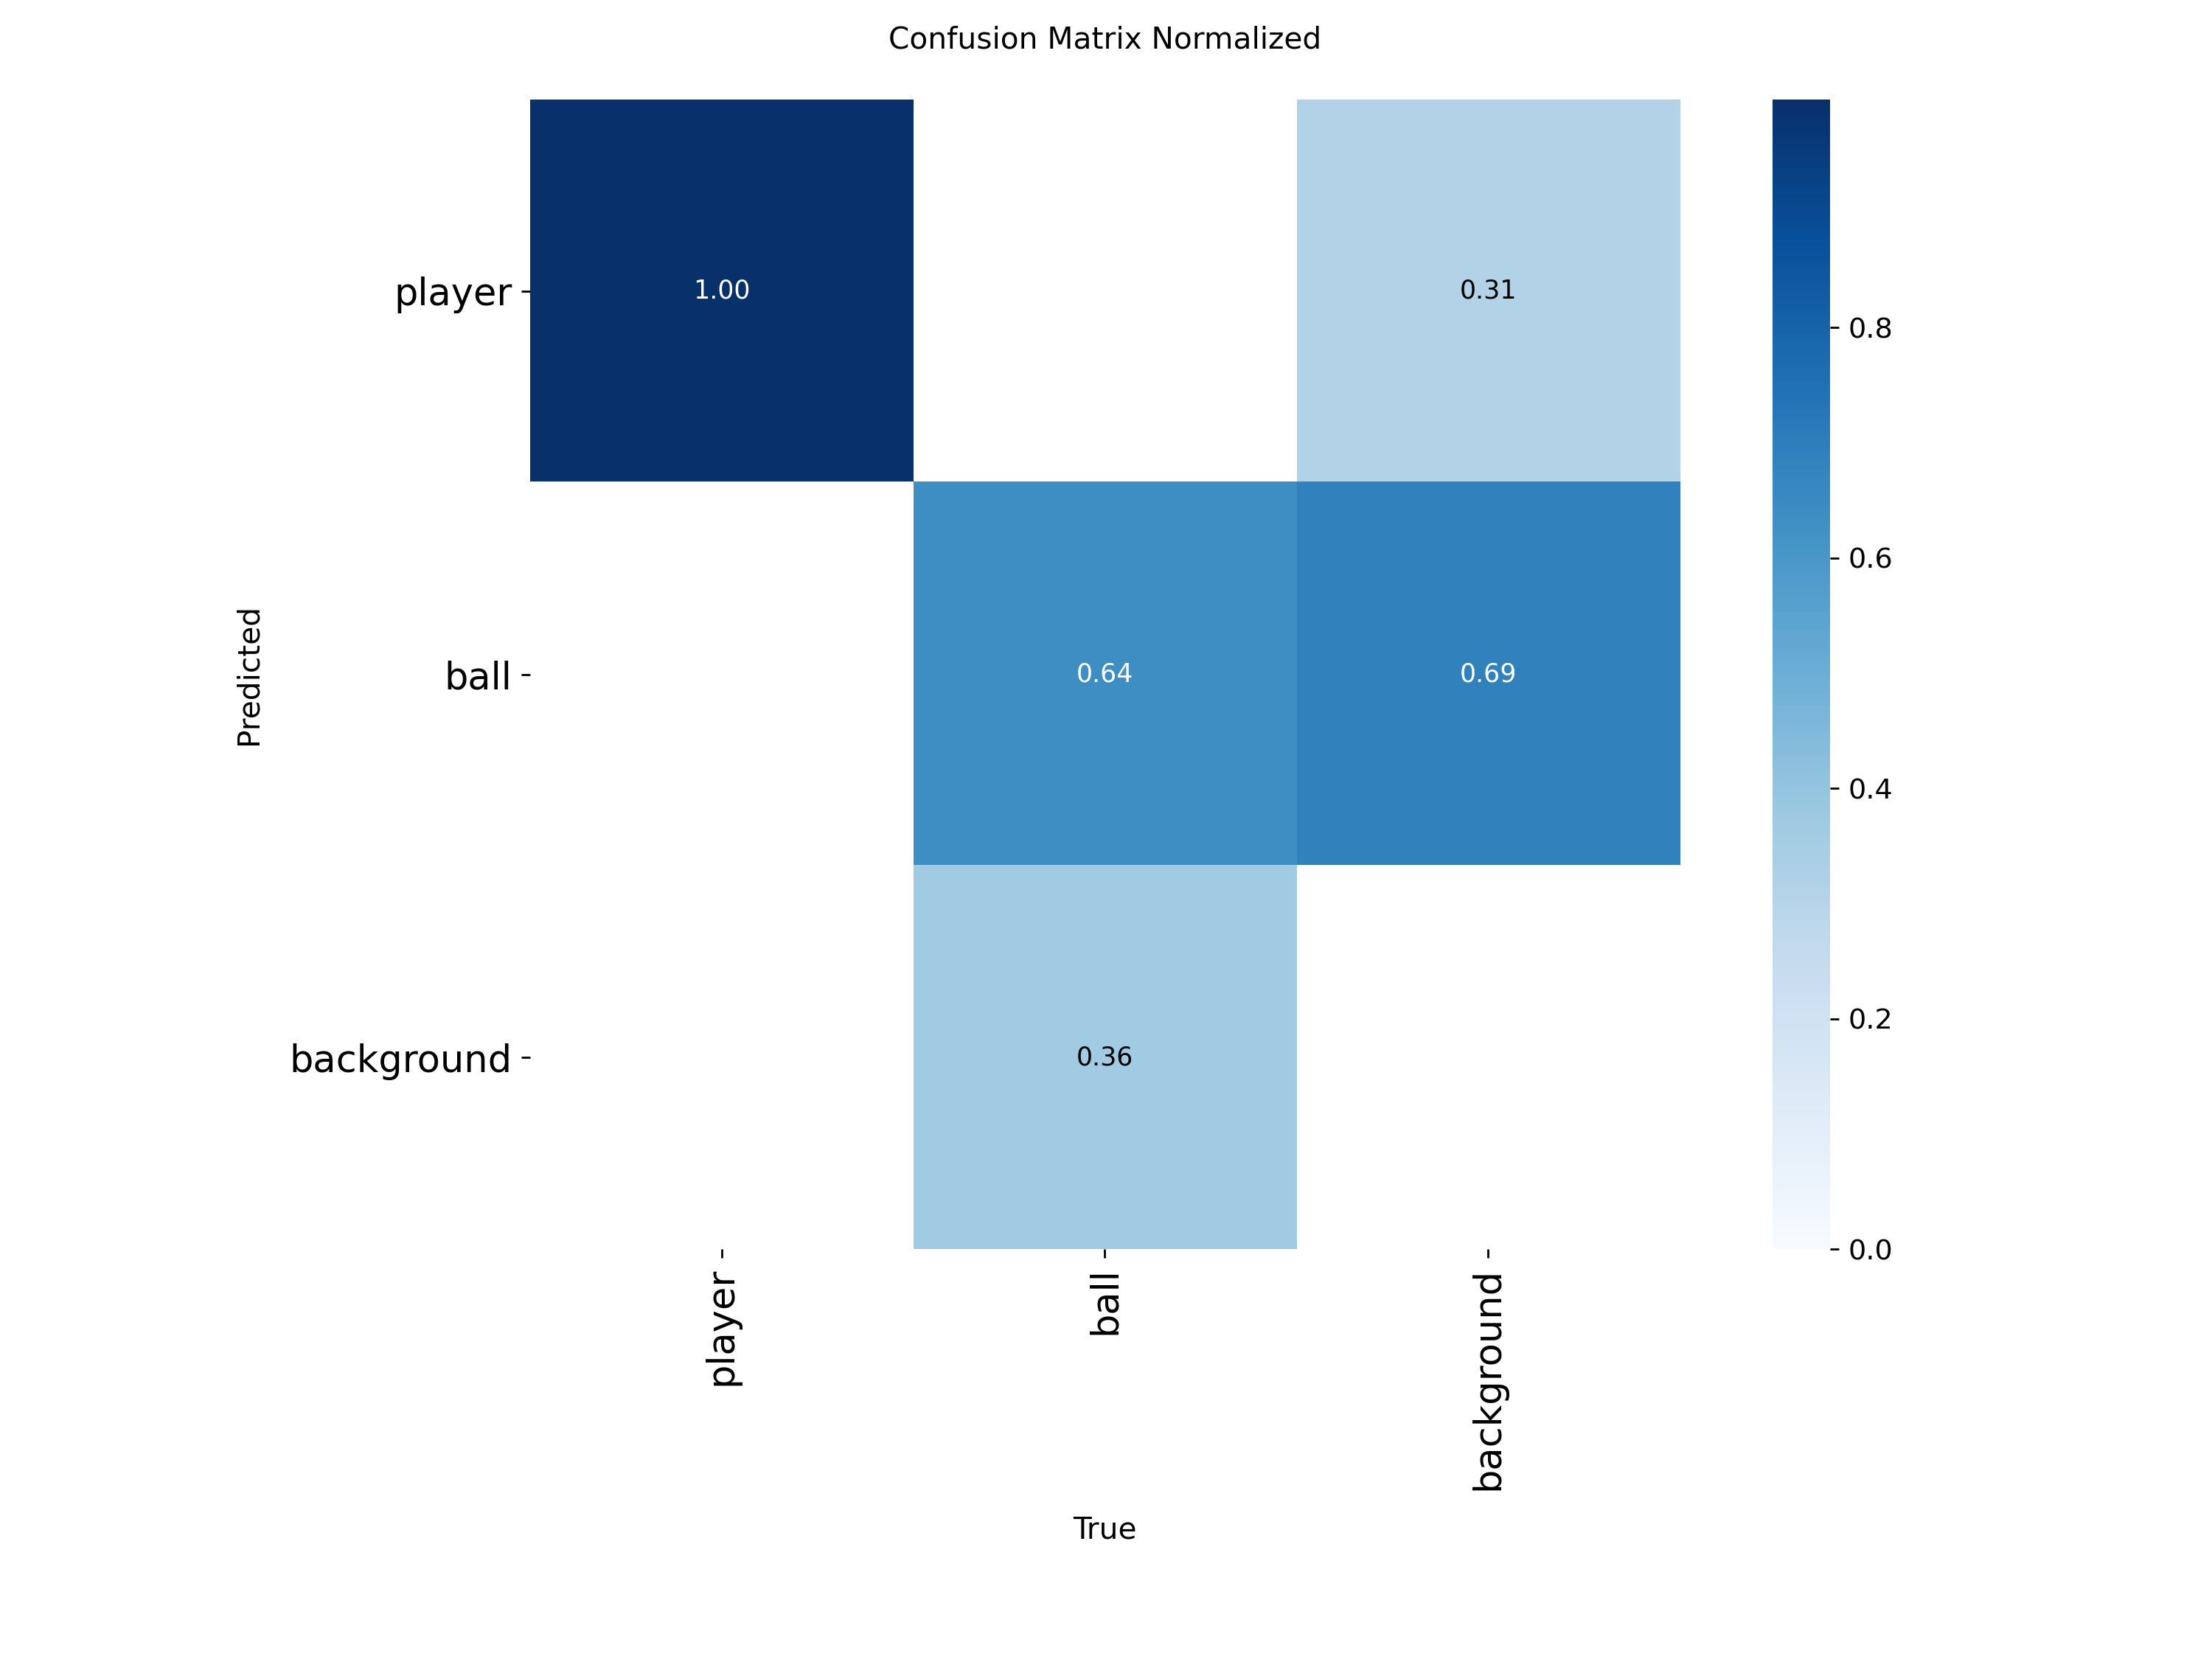

In [ ]:
display(Image(filename=os.path.join(runs_dir, 'yolo11n_soccer_final-3', 'confusion_matrix_normalized.png')))

## Análisis de las gráficas
En las gráficas de entrenamiento observamos que las pérdidas disminuyeron progresivamente. Esto indica que el modelo aprendió correctamente sin problemas severos de sobreajuste, ya que las curvas de validación mantuvieron un comportamiento estable.

Las métricas de precision, recall y mAP mostraron tendencia creciente, confirmando que las tres fases de fine-tuning mejoraron gradualmente el desempeño.

La curva F1 muestra diferencias entre clases. La clase player alcanzó valores F1 mucho más altos que ball. Esto confirma que fue más fácil detectar jugadores que el balón. La razón principal es que los jugadores ocupan mayor región y tienen características visuales consistentes, mientras que el balón es pequeño con cambios rápidos y muchas veces es tapado por algún jugador.

La matriz de confusión normalizada muestra que los jugadores obtuvieron desempeño muy alto. Mientras que ball obtuvo más errores y confusión con el fondo. Esto significa que en varios frames no detectamos correctamente el balón o generamos detecciones poco confiables.

Debido a estas limitaciones, implementamos técnicas adicionales de post-procesamiento y tracking del balón durante la inferencia. Los resultados demuestran que nuestro modelo cumplió satisfactoriamente con los objetivos del proyecto.

#### Procesamiento de Video

Antes de procesar el video, definimos diferentes parámetros para las áreas de análisis, tracking del balón y estabilización. Estas configuraciones permitieron generar correctamente los visual analytics solicitados.

Definimos manualmente las coordenadas de la cancha usando arreglos de puntos en formato poligonal. El polígono COURT representa los límites del campo, HALFWAY_X define la línea media para separar izquierda y derecha, y LEFT_PENALTY y RIGHT_PENALTY representan las áreas de penal.

Estas coordenadas fueron ajustadas manualmente usando la perspectiva del dron. Después utilizamos estas regiones en operaciones geométricas para determinar si jugadores o balón estaban dentro o fuera de zonas específicas.

Después inicializamos variables para tracking y suavizado del balón. Como es el objeto más difícil de detectar, almacenamos posiciones históricas recientes (ball_history) para mantener continuidad. Además definimos parámetros como:

- Distancia máxima permitida entre detecciones consecutivas (MAX_BALL_JUMP)
- Factores de suavizado para el bounding box (SMOOTH_BOX)
- Suavizado del valor de confianza (SMOOTH_CONF)
- Umbrales mínimos de confianza para jugadores y balón.

Estos parámetros reducen falsos positivos y evitan movimientos bruscos en la detección del balón.

Implementamos un sistema de estabilización con el algoritmo ORB (Oriented FAST and Rotated BRIEF). Primero seleccionamos un frame de referencia y extrajimos puntos característicos con ORB. Durante el procesamiento, comparamos estos puntos contra los frames actuales para calcular desplazamientos de cámara causados por el dron.

Finalmente, cargamos una imagen PNG transparente (lineas.png) con las líneas de la cancha. Esta imagen funciona como overlay gráfico que superponemos en cada frame para mejorar la visualización de las regiones. Esta fue la solución más simple que pudimos encontrar que funcionara y fuera fácil de implementar.

In [ ]:
# Coordenadas del campo
COURT = np.array([
    [0, 166], [1153, 125], [1226, 232], [1213, 592], [1137, 662], [64, 647]
], dtype=np.int32)

HALFWAY_X = 605

LEFT_PENALTY = np.array([
    [0, 297], [129, 303], [152, 311], [183, 360], [180, 361],
    [170, 416], [138, 438], [116, 448], [0, 448]
], dtype=np.int32)

RIGHT_PENALTY = np.array([
    [1031, 385], [1040, 352], [1085, 324], [1092, 319], [1222, 323],
    [1217, 475], [1071, 459], [1058, 455], [1028, 405]
], dtype=np.int32)

# Ball tracking
ball_history = []
MAX_HISTORY, MAX_FRAMES_PRED = 5, 8
frames_sin_bal, last_ball_det = 0, None
smooth_ball_box, smooth_ball_conf = None, None
MAX_BALL_JUMP, SMOOTH_BOX, SMOOTH_CONF = 120, 0.65, 0.7
CONF_THRESHOLD_PLAYERS, CONF_THRESHOLD_BALL = 0.45, 0.30

# Estabilización ORB
orb = cv2.ORB_create(300)
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
cap_ref = cv2.VideoCapture(video_path)
_, ref_frame = cap_ref.read()
cap_ref.release()
ref_gray = cv2.cvtColor(cv2.resize(ref_frame, (640, 360)), cv2.COLOR_BGR2GRAY)
kp_ref, des_ref = orb.detectAndCompute(ref_gray, None)

# Overlay del campo
overlay_img = cv2.imread(os.path.join(base_dir, "lineas.png"), cv2.IMREAD_UNCHANGED)
overlay_bgr = overlay_img[:, :, :3]

print("Configuración lista")

Configuración lista


Implementamos una función de post-procesamiento para reducir conflictos entre detecciones superpuestas, especialmente cuando el modelo detecta simultáneamente jugadores y balón en regiones similares.

La función separa las detecciones en dos grupos: jugadores y balones. Después calculamos el Intersection over Union (IoU) entre cada balón y jugador. IoU es una métrica que mide el nivel de superposición entre bounding boxes.

Si el IoU entre balón y jugador supera 0.3, consideramos que hay conflicto. Para resolverlo, comparamos el nivel de confianza de cada objeto y eliminamos aquella con menor probabilidad.

Este post-procesamiento fue importante para mejorar la detección del balón. Debido a su tamaño y cercanía con jugadores, el modelo generaba falsas detecciones. Con esta función reducimos errores y obtuvimos detecciones consistentes.

In [ ]:
def resolver_conflictos_detecciones(detecciones):
    if len(detecciones) < 2:
        return detecciones

    balones = [d for d in detecciones if d[5] == 1]
    jugadores = [d for d in detecciones if d[5] == 0]

    def iou(box1, box2):
        x1, y1, x2, y2 = box1[:4]
        x3, y3, x4, y4 = box2[:4]
        inter_w = max(0, min(x2, x4) - max(x1, x3))
        inter_h = max(0, min(y2, y4) - max(y1, y3))
        inter = inter_w * inter_h
        union = (x2 - x1) * (y2 - y1) + (x4 - x3) * (y4 - y3) - inter
        return inter / union if union > 0 else 0

    eliminar = set()
    for i, balon in enumerate(balones):
        for j, jugador in enumerate(jugadores):
            if iou(balon, jugador) > 0.3:
                if balon[4] < jugador[4]:
                    eliminar.add(('balon', i))
                else:
                    eliminar.add(('jugador', j))

    return [b for i, b in enumerate(balones) if ('balon', i) not in eliminar] + \
           [j for i, j in enumerate(jugadores) if ('jugador', i) not in eliminar]

#### Procesamiento del Video Completo

Para procesar el video, cargamos el modelo entrenado y abrimos el video original con OpenCV. Obtuvimos propiedades importantes como cantidad total de frames, resolución y FPS, necesarias para generar el video de salida.

Procesamos el video frame por frame. Antes de inferencia, aplicamos estabilización cada ciertos frames (frame_skip = 5). El frame actual se compara contra el de referencia con ORB y feature matching. Calculamos desplazamiento (dx, dy) para mantener alineado el overlay de la cancha.

Después de la estabilización, realizamos inferencia con YOLO. El modelo generó detecciones de jugadores y balón, incluyendo:

- Coordenadas de bounding boxes.
- Clase detectada.
- Nivel de confianza.

Filtramos las detecciones con umbrales de confianza distintos para jugadores y balón. Esto eliminó detecciones poco confiables y redujo falsos positivos.

Después aplicamos Non-Maximum Suppression (NMS) para eliminar detecciones duplicadas superpuestas, conservando las de mayor confianza. Luego pasaron por la función de resolución de conflictos para eliminar conflictos entre jugadores y balón.

Con las detecciones finales, separamos objetos por clase e iniciamos tracking del balón. Como es el más difícil, comparamos su posición actual con frames anteriores. Si el desplazamiento es muy grande, descartamos la detección.

Aplicamos suavizado en las coordenadas y nivel de confianza del balón con promedios ponderados. Esto estabilizó el movimiento visual y redujo vibraciones entre frames.

Dibujamos las detecciones en cada frame:

- Cuadros rojos para jugadores.
- Cuadros azules para el balón.
- Etiquetas con el nivel de confianza.

Después calculamos los visual analytics. Obtuvimos el centroide de cada jugador y lo comparamos contra las coordenadas de la cancha y áreas de penal.

Calculamos automáticamente:

- Cantidad de jugadores en lado izquierdo.
- Cantidad de jugadores en lado derecho.
- Jugadores fuera del campo.
- Jugadores en áreas de penal.
- Posición del balón dentro o fuera.

Superpusimos el overlay visual de las líneas usando transparencia (alpha blending). El overlay permaneció alineado gracias al desplazamiento calculado con ORB.

Agregamos un panel informativo mostrando todas las métricas en tiempo real. Almacenamos cada frame en el video de salida y al finalizar guardamos automáticamente el archivo con todas las detecciones y analytics.

In [ ]:
# Cargar modelo final
final_model_path = os.path.join(base_dir, "yolo11n_soccer_best.pt")
inference_model = YOLO(final_model_path)

# Abrir video
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Crear video de salida
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(output_video_path, fourcc, fps, (W, H))

frame_num = 0
dx, dy = 0, 0
frame_skip = 5

print(f"Procesando {total} frames...\n")

while cap.isOpened():
    ok, frame = cap.read()
    if not ok:
        break

    # Estabilización cada frame_skip frames
    if frame_num % frame_skip == 0:
        small = cv2.resize(frame, (640, 360))
        frame_gray = cv2.cvtColor(small, cv2.COLOR_BGR2GRAY)
        kp2, des2 = orb.detectAndCompute(frame_gray, None)

        if des2 is not None and des_ref is not None:
            matches = bf.match(des_ref, des2)
            matches = sorted(matches, key=lambda x: x.distance)
            good_matches = matches[:40]

            if len(good_matches) > 10:
                shifts_x = [kp2[m.trainIdx].pt[0] - kp_ref[m.queryIdx].pt[0] for m in good_matches]
                shifts_y = [kp2[m.trainIdx].pt[1] - kp_ref[m.queryIdx].pt[1] for m in good_matches]
                dx = int(np.median(shifts_x) * 2)
                dy = int(np.median(shifts_y) * 2)

    # Inferencia
    res = inference_model.predict(
        source=frame,
        imgsz=640,
        conf=0.25,
        verbose=False
    )

    # Procesar resultados
    todas_las_detecciones = []
    for box in res[0].boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        bx1, by1, bx2, by2 = map(int, box.xyxy[0].tolist())

        if cls_id == 0 and conf < CONF_THRESHOLD_PLAYERS:
            continue
        elif cls_id == 1 and conf < CONF_THRESHOLD_BALL:
            continue

        todas_las_detecciones.append([bx1, by1, bx2, by2, conf, cls_id])

    # NMS
    detecciones_finales = []
    for cls_id in [0, 1]:
        cajas_cls = [[d[0], d[1], d[2], d[3]] for d in todas_las_detecciones if d[5] == cls_id]
        scores_cls = [d[4] for d in todas_las_detecciones if d[5] == cls_id]
        indices_cls = [i for i, d in enumerate(todas_las_detecciones) if d[5] == cls_id]

        if len(cajas_cls) == 0:
            continue

        cajas_nms = [[c[0], c[1], c[2] - c[0], c[3] - c[1]] for c in cajas_cls]
        nms_idx = cv2.dnn.NMSBoxes(cajas_nms, scores_cls, 0.0, 0.45)

        if len(nms_idx) > 0:
            for i in nms_idx.flatten():
                detecciones_finales.append(todas_las_detecciones[indices_cls[i]])

    # Resolver conflictos
    detecciones_finales = resolver_conflictos_detecciones(detecciones_finales)

    # Separar por clase
    balones_det = [d for d in detecciones_finales if d[5] == 1]
    jugadores_det = [d for d in detecciones_finales if d[5] == 0]

    ball_detectado_este_frame = False

    # Tracking del balón
    if len(balones_det) > 0:
        balones_det.sort(key=lambda d: d[4], reverse=True)
        mejor_balon = None

        for candidato in balones_det:
            bx1, by1, bx2, by2 = candidato[0], candidato[1], candidato[2], candidato[3]
            bcx = (bx1 + bx2) // 2
            bcy = (by1 + by2) // 2

            if last_ball_det is not None:
                last_cx = (last_ball_det[0] + last_ball_det[2]) // 2
                last_cy = (last_ball_det[1] + last_ball_det[3]) // 2
                dist = np.sqrt((bcx - last_cx)**2 + (bcy - last_cy)**2)

                if dist > MAX_BALL_JUMP:
                    continue

            mejor_balon = candidato
            break

        if mejor_balon is not None:
            bx1, by1, bx2, by2 = mejor_balon[0], mejor_balon[1], mejor_balon[2], mejor_balon[3]
            conf_ball = mejor_balon[4]

            nueva_caja = np.array([bx1, by1, bx2, by2], dtype=np.float32)
            if smooth_ball_box is None:
                smooth_ball_box = nueva_caja
            else:
                smooth_ball_box = SMOOTH_BOX * nueva_caja + (1 - SMOOTH_BOX) * smooth_ball_box

            bx1, by1, bx2, by2 = smooth_ball_box.astype(int)

            if smooth_ball_conf is None:
                smooth_ball_conf = conf_ball
            else:
                smooth_ball_conf = SMOOTH_CONF * conf_ball + (1 - SMOOTH_CONF) * smooth_ball_conf

            bcx = (bx1 + bx2) // 2
            bcy = (by1 + by2) // 2

            ball_history.append((frame_num, bcx, bcy))
            if len(ball_history) > MAX_HISTORY:
                ball_history.pop(0)

            last_ball_det = [bx1, by1, bx2, by2]
            frames_sin_bal = 0
            ball_detectado_este_frame = True

            cv2.rectangle(frame, (bx1, by1), (bx2, by2), (255, 0, 0), 2)
            cv2.putText(frame, f"B {smooth_ball_conf:.2f}", (bx1, by1 - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1)
        else:
            frames_sin_bal += 1

    # Dibujar jugadores
    for x1, y1, x2, y2, conf, cls_id in jugadores_det:
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 0, 255), 2)
        cv2.putText(frame, f"P {conf:.2f}", (x1, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)

    # Calcular analytics
    left_players = 0
    right_players = 0
    out_players = 0
    left_penalty = 0
    right_penalty = 0
    ball_side = "No detectado"

    for x1, y1, x2, y2, conf, cls_id in jugadores_det:
        cx = (x1 + x2) // 2
        cy = (y1 + y2) // 2

        in_court = cv2.pointPolygonTest(COURT, (float(cx), float(cy)), False) >= 0

        if not in_court:
            out_players += 1
        elif cx < HALFWAY_X:
            left_players += 1
            if cv2.pointPolygonTest(LEFT_PENALTY, (float(cx), float(cy)), False) >= 0:
                left_penalty += 1
        else:
            right_players += 1
            if cv2.pointPolygonTest(RIGHT_PENALTY, (float(cx), float(cy)), False) >= 0:
                right_penalty += 1

    if last_ball_det is not None:
        bcx = (last_ball_det[0] + last_ball_det[2]) // 2
        bcy = (last_ball_det[1] + last_ball_det[3]) // 2
        in_court = cv2.pointPolygonTest(COURT, (float(bcx), float(bcy)), False) >= 0
        if not in_court:
            ball_side = "Fuera del campo"
        elif bcx < HALFWAY_X:
            ball_side = "Lado izquierdo" if ball_detectado_este_frame else "Lado izquierdo (pred)"
        else:
            ball_side = "Lado derecho" if ball_detectado_este_frame else "Lado derecho (pred)"

    # Overlay
    if overlay_img is not None:
        ov  = overlay_img
        oh, ow = ov.shape[:2]

        px = dx
        py = dy

        src_x0 = max(0, -px)
        src_y0 = max(0, -py)
        dst_x0 = max(0, px)
        dst_y0 = max(0, py)
        src_x1 = min(ow, W - px)
        src_y1 = min(oh, H - py)

        if src_x1 > src_x0 and src_y1 > src_y0:
            ov_crop = ov[src_y0:src_y1, src_x0:src_x1]
            dst_x1 = dst_x0 + ov_crop.shape[1]
            dst_y1 = dst_y0 + ov_crop.shape[0]

            if dst_x1 <= W and dst_y1 <= H and ov_crop.shape[2] == 4:
                alpha = ov_crop[:, :, 3:4] / 255.0
                ov_rgb = ov_crop[:, :, :3]
                roi = frame[dst_y0:dst_y1, dst_x0:dst_x1]
                frame[dst_y0:dst_y1, dst_x0:dst_x1] = (alpha * ov_rgb + (1 - alpha) * roi).astype(np.uint8)

    # Panel de analytics
    overlay_panel = frame.copy()
    cv2.rectangle(overlay_panel, (0, 0), (W, 65), (0, 0, 0), -1)
    cv2.addWeighted(overlay_panel, 0.5, frame, 0.5, 0, frame)

    total_players = left_players + right_players + out_players
    linea1 = (f"Jugadores: {total_players}   Izq: {left_players}   "
              f"Der: {right_players}   Fuera: {out_players}")
    linea2 = (f"Penal izq: {left_penalty}   Penal der: {right_penalty}   "
              f"Balon: {ball_side}")

    cv2.putText(frame, linea1, (10, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1)
    cv2.putText(frame, linea2, (10, 48), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1)

    writer.write(frame)
    frame_num += 1
    if frame_num % 300 == 0:
        print(f"  {frame_num}/{total} frames procesados...")

cap.release()
writer.release()
print(f"\nVideo guardado en: {output_video_path}")

Procesando 3846 frames...

  300/3846 frames procesados...
  600/3846 frames procesados...
  900/3846 frames procesados...
  1200/3846 frames procesados...
  1500/3846 frames procesados...
  1800/3846 frames procesados...
  2100/3846 frames procesados...
  2400/3846 frames procesados...
  2700/3846 frames procesados...
  3000/3846 frames procesados...
  3300/3846 frames procesados...
  3600/3846 frames procesados...

Video guardado en: /content/drive/MyDrive/FinalProject_SportsAnalytics/output_detections.mp4


#### Conclusiones

Este proyecto nos permitió comprender mejor un área de la inteligencia artificial que no habíamos explorado profundamente: el análisis de video usando visión computacional y deep learning. A lo largo del desarrollo observamos cómo un modelo de detección de objetos puede aplicarse a un problema real de análisis deportivo, permitiendo automatizar tareas que normalmente requerirían revisión manual y consumirían mucho tiempo.
La parte más desafiante del proyecto fue lograr una detección estable y precisa del balón. A diferencia de los jugadores que ocupan una región más grande con características visuales consistentes, el balón es un objeto mucho más pequeño dentro de la escena. Presenta movimientos rápidos, cambios bruscos de posición y oclusiones provocadas por los jugadores. Debido a esto, además del entrenamiento del modelo YOLO, fue necesario implementar técnicas adicionales de tracking y suavizado para mejorar la estabilidad de las detecciones en el video final.
De igual manera, la implementación del overlay de líneas estabilizado ayudó a que la representación visual del campo fuera más clara y consistente para el usuario final. Aunque las líneas mostradas funcionan principalmente como apoyo visual, los análisis y métricas del sistema realmente se calcularon utilizando polígonos y coordenadas definidas manualmente. Esto permitió obtener resultados más confiables al momento de determinar si jugadores o balón se encontraban dentro o fuera de ciertas regiones del campo.
Finalmente, consideramos que los resultados fueron satisfactorios. El sistema logró detectar jugadores y balón de manera funcional y además generó automáticamente diferentes métricas visuales sobre el partido. El proyecto reforzó nuestro conocimiento sobre transfer learning, entrenamiento de redes neuronales, procesamiento de video y técnicas de postprocesamiento para mejorar resultados en aplicaciones reales de inteligencia artificial.
